In [2]:
# IMPORTS
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
# CHART STYLING
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

print('Imports complete')

Imports complete


In [4]:
# LOAD RAW DATA
raw_df = pd.read_csv('../data/online_retail_II.csv')
raw_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### BUILDING A PURCHASE-LEVEL TABLE
- IN order to have a foundation for all hypotheses queries
- Creating a one row per unique customer invoice combination
- A table all hypotheses run from

In [ ]:
# PURCHASE-LEVEL TABLE

# creating the table
purchases = df.groupby(
    ['Customer ID', 'Invoice', 'InvoiceDate']
).agg(
    total_items = ('Quantity', 'sum'),
    total_revenue = ('Revenue', 'sum')
).reset_index()

# sorting by customer and date for sequential analysis
purchases = purchases.sort_values(['Customer ID', 'InvoiceDate']).reset_index()

# ranking each invoice per customer
purchases['purchase_rank'] = purchases.groupby('Customer ID')['InvoiceDate'].rank(method = 'first').astype(int)

# viewing result
print(f"Purchase-level table built")
print(f"Total purchase records: {len(purchases):,}")
print(f"\nSample:")
print(purchases.head(10))


Purchase-level table built
Total purchase records: 37,039

Sample:
   index  Customer ID Invoice         InvoiceDate  total_items  total_revenue  \
0      0        12346  491725 2009-12-14 08:34:00           10          45.00   
1      1        12346  491742 2009-12-14 11:00:00            5          22.50   
2      2        12346  491744 2009-12-14 11:02:00            5          22.50   
3      3        12346  492718 2009-12-18 10:47:00            5          22.50   
4      4        12346  492722 2009-12-18 10:55:00            1           1.00   
5      5        12346  493410 2010-01-04 09:24:00            5          22.50   
6      6        12346  493412 2010-01-04 09:53:00            5          22.50   
7      7        12346  494450 2010-01-14 13:50:00            5          22.50   
8      8        12346  495295 2010-01-22 13:30:00            5          22.50   
9      9        12346  499763 2010-03-02 13:08:00            5          27.05   

   purchase_rank  
0              1  
1  


=== One-Time vs Repeat Buyers ===
    buyer_type  count  percentage
  repeat_buyer   4255        72.4
one_time_buyer   1626        27.6


NameError: name 'fig' is not defined

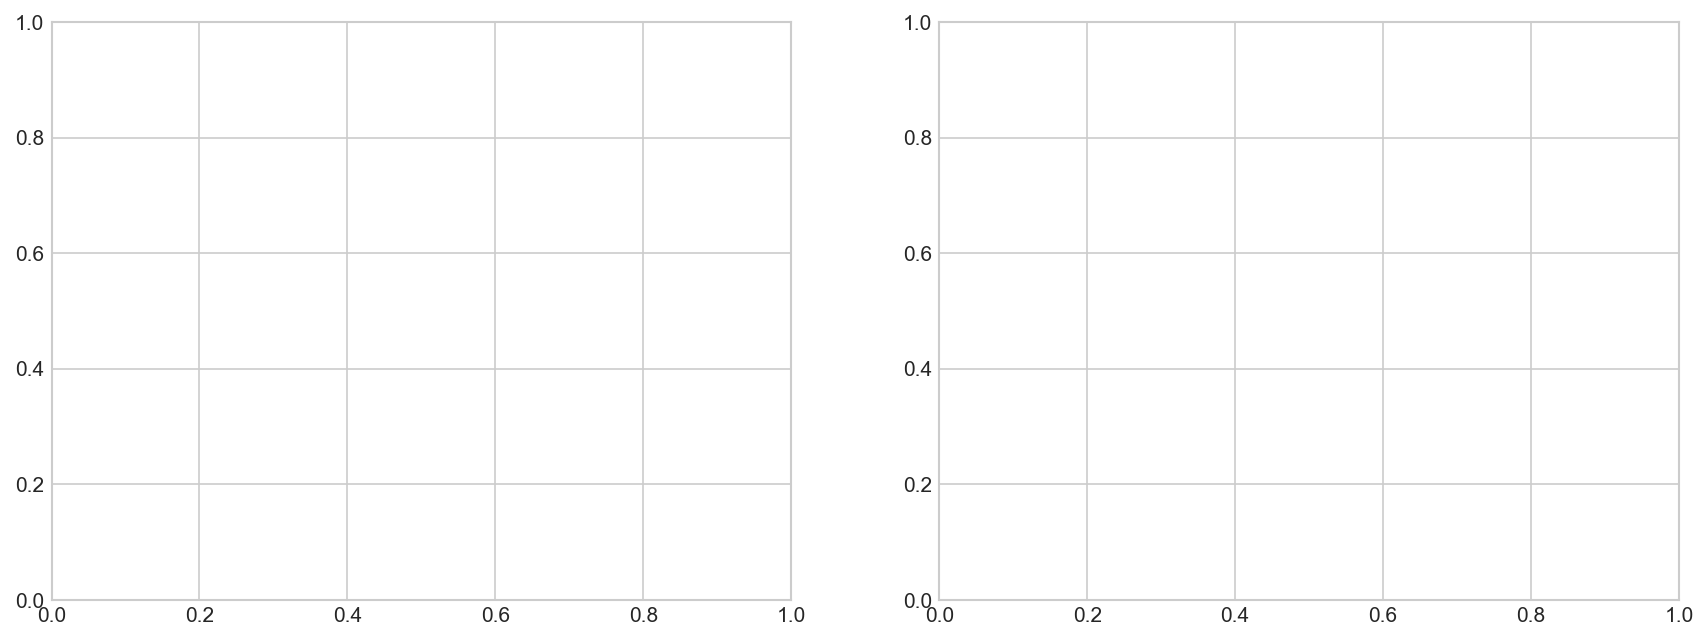

In [ ]:
# HYPOTHESIS 1
# Most customers do not return after their first purchase

print("HYPOTHESIS 1: Do Most Customers Return?")
print("=" * 20)

# counting the invoices per customer
purchase_counts = purchases.groupby('Customer ID')['Invoice'].nunique()\
    .reset_index().rename(columns = {'Invoice' : 'total_purchases'})

# label repeat and one-time buyers
purchase_counts['buyer_type'] = purchase_counts['total_purchases']\
    .apply(lambda x: 'one_time_buyer' if x == 1  else 'repeat_buyer')

# summarize
summary = purchase_counts['buyer_type'].value_counts().reset_index()
summary.columns = ['buyer_type', 'count']
summary['percentage'] = (
    summary['count']/len(purchase_counts) * 100
).round(1)

# VISUALIZING THE RESULT

print('\n=== One-Time vs Repeat Buyers ===')
print(summary.to_string(index = False))

# purchase frequency distribution
freq_dist = purchase_counts['total_purchases'].clip(upper = 20)\
    .value_counts().sort_index()

# visualize
fig.axes = plt.subplots(1, 2, figsize = (14, 5))

# bar chart
colors = [
    '#2196F3' if bt == 'repeat_buyer' else '#bB0BEC5' for bt in summary['buyer_type']
]
bars = axes[0].bar(
    summary['buyer_type'],
    summary['percentage'],
    color = colors,
    edgecolor = 'white',
    width = 0.4
)
axes[0].set_title(
    'One-Time vs Repeat Buyers',
    fontweight='bold', fontsize=12
)
axes[0].set_ylabel('Percentage of Customers (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, summary['percentage']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val}%',
        ha='center', fontweight='bold', fontsize=13
    )

# Frequency distribution
axes[1].bar(
    freq_dist.index,
    freq_dist.values,
    color='#2196F3',
    edgecolor='white'
)
axes[1].set_title(
    'Purchase Frequency Distribution',
    fontweight='bold', fontsize=12
)
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticks(range(1, 21))

# Confirmation check
one_time_pct = summary[
    summary['buyer_type'] == 'one_time_buyer'
]['percentage'].values[0]

result = 'CONFIRMED' if one_time_pct > 50 else 'REJECTED'
print(f"\nOne-time buyers: {one_time_pct}%")
print(f"Hypothesis 1: {result}")

plt.suptitle(
    f'H1: Do Most Customers Return? — {result}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/hypothesis_1_repeat_buyers.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
